In [34]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

Load the dataset

In [ ]:
# dataset path with fallback

df = pd.read_csv("amazon.csv")
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded dataset: 1,465 rows, 16 columns


Explore the dataset

In [36]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [37]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

Drop the missing values

In [38]:
df = df.dropna(subset=['rating_count'])
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [39]:
print("Columns:\n", df.columns.tolist())

Columns:
 ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


In [40]:
print("Shape:", df.shape)

Shape: (1463, 16)


In [41]:
print(df.dtypes)

product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object


In [42]:
df.size

23408

In [43]:
# check for duplicate products
duplicate_rows = df[df.duplicated(subset=['product_id'], keep=False)]
print('Total duplicate product rows found:', len(duplicate_rows))
print(f'Unique duplicate product IDs: {duplicate_rows["product_id"].nunique()}')

Total duplicate product rows found: 206
Unique duplicate product IDs: 92


In [44]:
print(df.describe(include='object'))

        product_id                                       product_name  \
count         1463                                               1463   
unique        1349                                               1335   
top     B07JW9H4J1  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...   
freq             3                                                  5   

                                                 category discounted_price  \
count                                                1463             1463   
unique                                                211              550   
top     Computers&Accessories|Accessories&Peripherals|...             ₹199   
freq                                                  231               52   

       actual_price discount_percentage rating rating_count  \
count          1463                1463   1463         1463   
unique          449                  92     28         1143   
top            ₹999                 50%    4.1        

In [45]:
print('Before dedup:', df.shape)

df = df.drop_duplicates(subset=['product_id'], keep='first')

print('After dedup stage 1 (unique products):', df.shape)

Before dedup: (1463, 16)
After dedup stage 1 (unique products): (1349, 16)


Extract columns from already existing columns


In [46]:
df["num_reviews"]=df["review_id"].astype(str).str.split(",").apply(len)

In [47]:
df["main_category"]=df["category"].apply(lambda x:str(x).split("|")[0].strip())

In [48]:
df["sub_category"]=df["category"].apply(lambda x:str(x).split("|")[-1].strip())

In [49]:
df["main_category"].value_counts()

main_category
Electronics              490
Home&Kitchen             448
Computers&Accessories    373
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

In [50]:
df["sub_category"].value_counts()

sub_category
USBCables               159
Smartphones              68
SmartWatches             62
SmartTelevisions         60
In-Ear                   51
                       ... 
RotiMakers                1
FanParts&Accessories      1
StandMixers               1
PedestalFans              1
HandheldBags              1
Name: count, Length: 207, dtype: int64

Dropping unnecessary columns

In [51]:
# drop columns 
drop_columns = {'category', 'about_product', 'img_link', 'product_link', 'user_id', 'user_name'}

In [52]:
df = df.drop(columns=[col for col in drop_columns if col in df.columns])
print(f"Shape after dropping auxiliary columns: {df.shape}")


Shape after dropping auxiliary columns: (1349, 13)


In [53]:
df.shape

(1349, 13)

Clean columns(standardized format)

In [54]:
price=["discounted_price","actual_price"]

In [55]:
price_cols = ['discounted_price', 'actual_price']
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(r'[₹,]', '', regex=True).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Price column null counts:')
print(df[price_cols].isnull().sum())

Price column null counts:
discounted_price    0
actual_price        0
dtype: int64


In [56]:
# drop duplicate listings with the same title prefix and identical reviews
df['product_name_base'] = df['product_name'].str[:50].str.strip()

print('Before variant dedup:', df.shape)
df = df.drop_duplicates(subset=['product_name_base', 'review_content'], keep='first')
print('After variant dedup:', df.shape)

print(df[df['product_name'].str.contains('PTron Newly Launched Force X10', case=False, na=False)]
      [['product_id', 'product_name', 'rating']])

df = df.drop(columns=['product_name_base'])

Before variant dedup: (1349, 14)
After variant dedup: (1308, 14)
     product_id                                       product_name rating
463  B0B53QFZPY  PTron Newly Launched Force X10 Bluetooth Calli...    3.3


In [57]:
df["discount_percentage"] = df["discount_percentage"].astype(str).str.replace("%", "", regex=False)
df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

In [58]:
print("Discount percentage range:", df["discount_percentage"].min(), "% to", df["discount_percentage"].max(), "%")
print("Null count in discount_percentage:", df["discount_percentage"].isnull().sum())

Discount percentage range: 0 % to 94 %
Null count in discount_percentage: 0


In [59]:
# remove row with non-numeric rating ('|')
invalid_ratings = df[df['rating'] == '|']
if len(invalid_ratings) > 0:
    print(f"Dropping {len(invalid_ratings)} row(s) with invalid rating '|': {invalid_ratings['product_id'].tolist()}")

df = df[df['rating'] != '|']
df['rating'] = pd.to_numeric(df['rating'])
print(f"Rating range: {df['rating'].min()} to {df['rating'].max()}")

Dropping 1 row(s) with invalid rating '|': ['B08L12N5H1']
Rating range: 2.0 to 5.0


In [60]:
df["rating_count"] = df["rating_count"].astype(str).str.replace(",", "", regex=False)
df["rating_count"] = pd.to_numeric(df["rating_count"])

In [61]:
df.head(2)

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,review_id,review_title,review_content,num_reviews,main_category,sub_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64,4.2,24269,"R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,8,Computers&Accessories,USBCables
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43,4.0,43994,"RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,8,Computers&Accessories,USBCables


In [62]:
import re

def clean_review_content(text):
    text = str(text).strip()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[\ufffd\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    
    # avoid splitting brand names when fixing glued camelCase words
    protected_brands = ['iPhone', 'OnePlus', 'boAt', 'YouTube', 'JioFiber', 'iPad', 'iMac', 'MacBook']
    for b in protected_brands:
        text = text.replace(b, f"__BRAND_{b}__")
    
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    
    for b in protected_brands:
        text = text.replace(f"__BRAND_{b}__", b)
    
    text = re.sub(r'\s+\.', '.', text)
    text = re.sub(r'\.', '. ', text) if False else text
    text = re.sub(r'\s+', ' ', text).strip()
    return text.strip('., ')

# avoid repeating title if body already starts with it
def combine_title_content(title, content):
    t = str(title).strip()
    c = str(content).strip()
    if not t or t.lower() == 'nan':
        return c
    if not c or c.lower() == 'nan':
        return t
    if c.lower().startswith(t.lower()):
        return c
    return f"{t}. {c}"

df['full_review'] = [combine_title_content(t, c) for t, c in zip(df['review_title'], df['review_content'])]
df['full_review_clean'] = df['full_review'].apply(clean_review_content)
df['word_count'] = df['full_review_clean'].apply(lambda x: len(str(x).split()))

print("Sample cleaned bundle review:")
print(df['full_review_clean'].iloc[0][:150] + '...')

Sample cleaned bundle review:
Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good Product,As of now seems good. Looks durable Charging i...


In [63]:
print('After dedup verification:', df.shape)
print('Duplicate product_ids remaining:', df['product_id'].duplicated().sum())
print('Duplicate full review bundles remaining:', df['full_review_clean'].duplicated().sum())

After dedup verification: (1307, 16)
Duplicate product_ids remaining: 0
Duplicate full review bundles remaining: 124


In [64]:
df.head(2)

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,review_id,review_title,review_content,num_reviews,main_category,sub_category,full_review,full_review_clean,word_count
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64,4.2,24269,"R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,8,Computers&Accessories,USBCables,"Satisfied,Charging is really fast,Value for mo...","Satisfied,Charging is really fast,Value for mo...",75
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43,4.0,43994,"RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,8,Computers&Accessories,USBCables,"A Good Braided Cable for Your Type C Device,Go...","A Good Braided Cable for Your Type C Device,Go...",228


In [65]:
import matplotlib.pyplot as plt 
import seaborn as sns


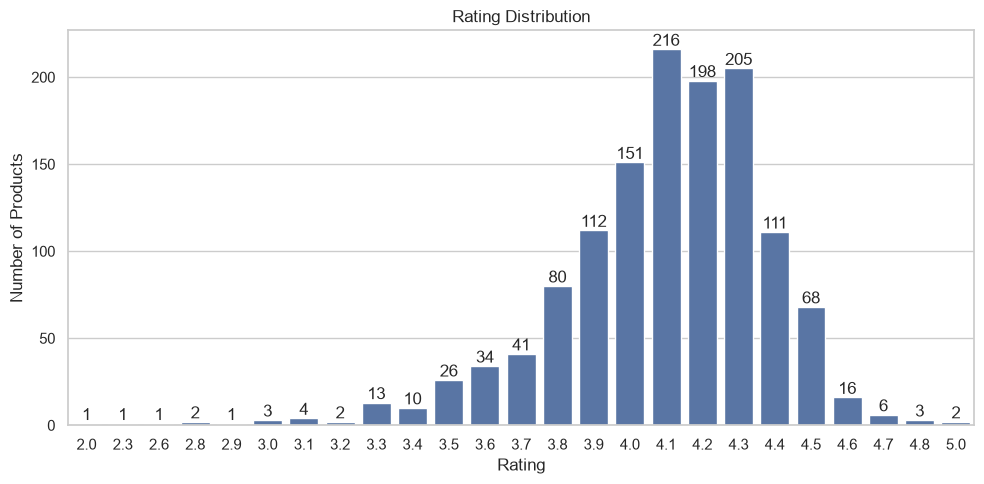

In [66]:
plt.figure(figsize=(10, 5))
ax=sns.countplot(data=df,x='rating')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.tight_layout()
ax.bar_label(ax.containers[0])
plt.show()


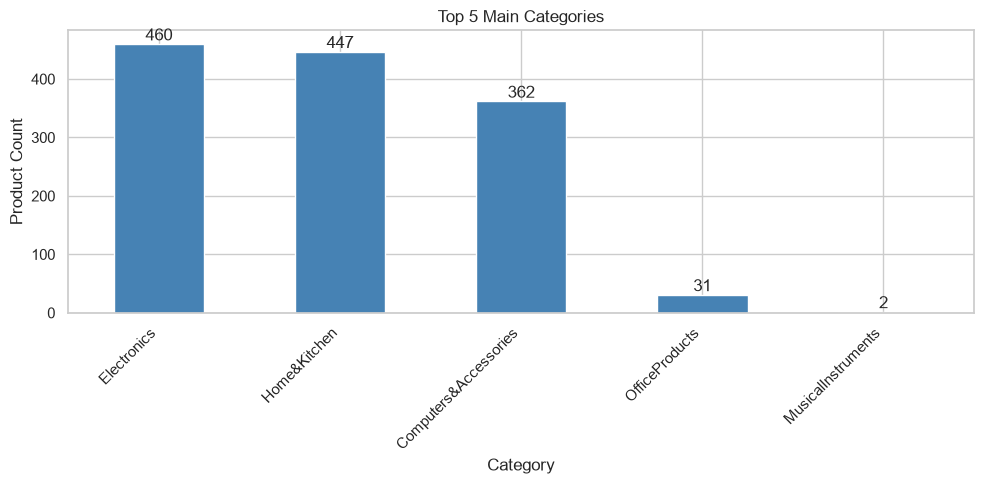

In [67]:
plt.figure(figsize=(10, 5))
g=df['main_category'].value_counts().head(5).plot(kind='bar', color='steelblue')
plt.title('Top 5 Main Categories')
plt.xlabel('Category')
plt.ylabel('Product Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
g=plt.bar_label(g.containers[0])
plt.show()


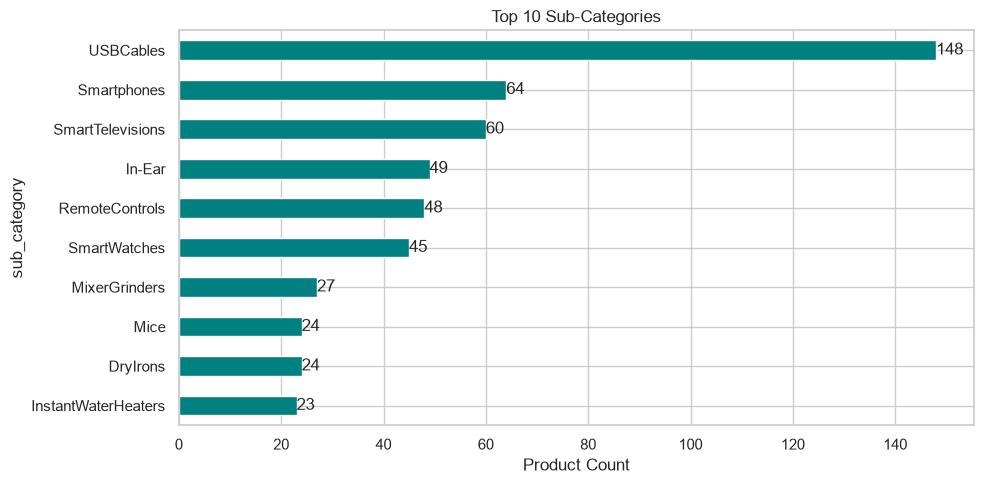

In [68]:
plt.figure(figsize=(10, 5))
g2=df['sub_category'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Sub-Categories')
plt.xlabel('Product Count')
plt.gca().invert_yaxis()
plt.tight_layout()
g2=plt.bar_label(g2.containers[0])
plt.show()


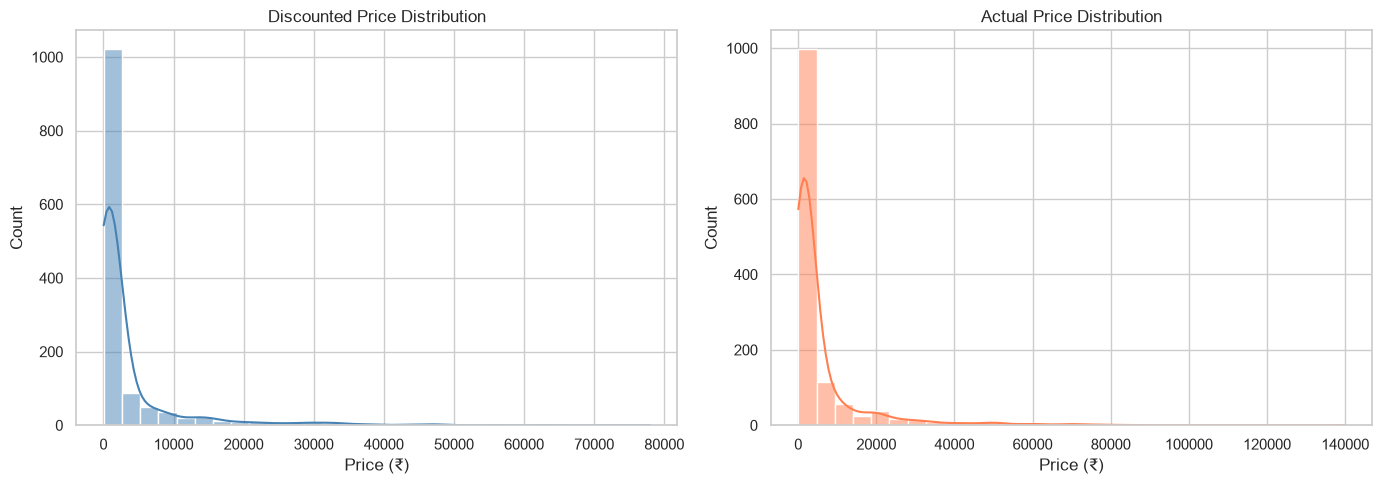

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['discounted_price'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Discounted Price Distribution')
axes[0].set_xlabel('Price (₹)')

sns.histplot(df['actual_price'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Actual Price Distribution')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
plt.show()


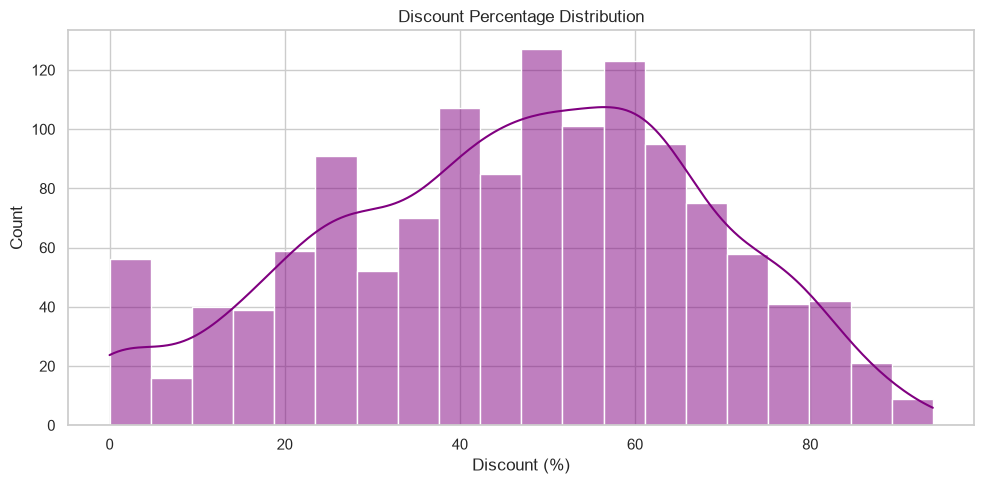

In [70]:
plt.figure(figsize=(10, 5))
sns.histplot(df['discount_percentage'], bins=20, kde=True, color='purple')
plt.title('Discount Percentage Distribution')
plt.xlabel('Discount (%)')
plt.tight_layout()
plt.show()


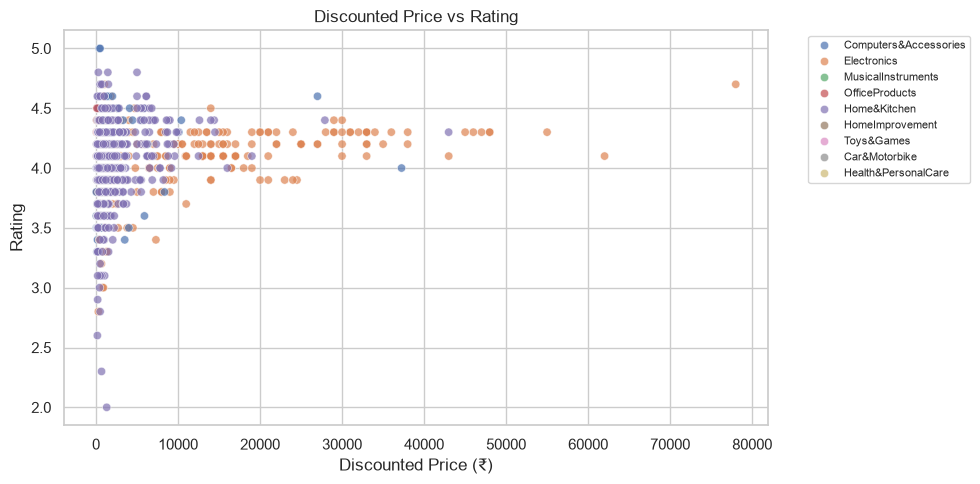

In [71]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='discounted_price', y='rating',
                hue='main_category', alpha=0.7)
plt.title('Discounted Price vs Rating')
plt.xlabel('Discounted Price (₹)')
plt.ylabel('Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


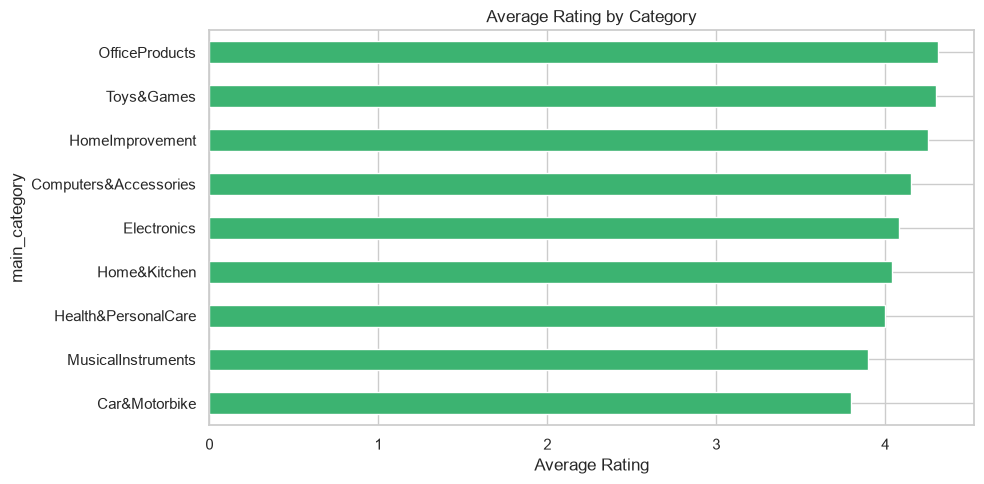

In [72]:
plt.figure(figsize=(10, 5))
df.groupby('main_category')['rating'].mean().sort_values()\
  .plot(kind='barh', color='mediumseagreen')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()


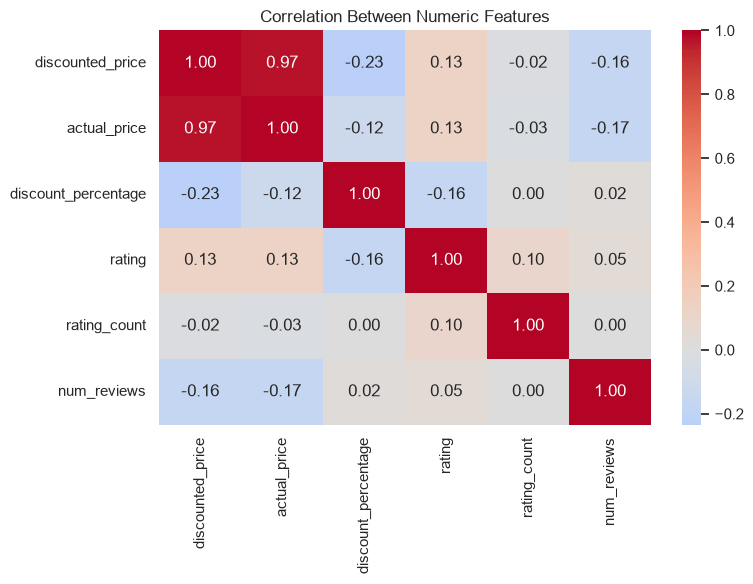

In [73]:
plt.figure(figsize=(8, 6))
numeric_cols = ['discounted_price', 'actual_price', 'discount_percentage',
                'rating', 'rating_count', 'num_reviews']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()


In [74]:
print("Total reviews:        ", len(df))
print("Unique products:      ", df['product_id'].nunique())
print("Unique categories:    ", df['main_category'].nunique())
print("Average rating:       ", round(df['rating'].mean(), 2))
print("Average word count:   ", round(df['word_count'].mean(), 1))

print("\nTop categories:")
print(df['main_category'].value_counts().head(10))

print("\nRating breakdown:")
print(df['rating'].value_counts().sort_index())

Total reviews:         1307
Unique products:       1307
Unique categories:     9
Average rating:        4.09
Average word count:    264.3

Top categories:
main_category
Electronics              460
Home&Kitchen             447
Computers&Accessories    362
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

Rating breakdown:
rating
2.0      1
2.3      1
2.6      1
2.8      2
2.9      1
3.0      3
3.1      4
3.2      2
3.3     13
3.4     10
3.5     26
3.6     34
3.7     41
3.8     80
3.9    112
4.0    151
4.1    216
4.2    198
4.3    205
4.4    111
4.5     68
4.6     16
4.7      6
4.8      3
5.0      2
Name: count, dtype: int64


## Part 2: Sentiment and Intent Analysis

In [75]:
# unpack bundled reviews into individual rows
import re
import pandas as pd

sample_title = str(df['review_title'].iloc[0])
expected     = int(df['num_reviews'].iloc[0]) if 'num_reviews' in df.columns else 8
pipe_n  = sample_title.count('|') + 1
comma_n = sample_title.count(',') + 1
sep = '|' if abs(pipe_n - expected) <= abs(comma_n - expected) else ','
print(f"Separator used: '{sep}' (pipe: {pipe_n}, comma: {comma_n}, expected: ~{expected})")

product_meta_cols = [
    'product_id', 'product_name', 'main_category', 'sub_category',
    'discounted_price', 'actual_price', 'discount_percentage',
    'rating', 'rating_count', 'num_reviews',
]

records = []
for _, row in df.iterrows():
    titles = [t.strip() for t in str(row['review_title']).split(sep)]
    if sep == ',':
        # split on comma followed by a capital letter/digit to avoid cutting sentences inside reviews
        contents = [c.strip() for c in re.split(r',\s*(?=[A-Z0-9"\'\-])', str(row['review_content']))]
    else:
        contents = [c.strip() for c in str(row['review_content']).split(sep)]
        
    review_ids = [r.strip() for r in str(row.get('review_id', '')).split(',')]
    n = max(len(titles), len(contents))
    
    for i in range(n):
        t = titles[i]   if i < len(titles)   else ''
        c = contents[i] if i < len(contents) else ''
        combined = combine_title_content(t, c)
        clean = clean_review_content(combined)
        if len(clean) > 3:
            rec = {col: row[col] for col in product_meta_cols if col in row.index}
            rec['review_idx']            = i
            rec['review_id_single']      = review_ids[i] if i < len(review_ids) else f"{row['product_id']}_rev_{i}"
            rec['review_title_single']   = t
            rec['review_content_single'] = c
            rec['review_clean']          = clean
            records.append(rec)

df_reviews = pd.DataFrame(records).reset_index(drop=True)

# drop duplicates under the same product
before_dedup = len(df_reviews)
df_reviews = df_reviews.drop_duplicates(subset=['product_id', 'review_clean'], keep='first').reset_index(drop=True)
print(f"Dropped {before_dedup - len(df_reviews)} duplicate reviews within products.")

print(f"\nExploded to {len(df_reviews):,} individual reviews across {df_reviews['product_id'].nunique():,} products")
print(f"Average reviews per product: {len(df_reviews) / df_reviews['product_id'].nunique():.1f}")
print(f"Average word count per review: {df_reviews['review_clean'].apply(lambda x: len(x.split())).mean():.1f}")

Separator used: ',' (pipe: 1, comma: 8, expected: ~8)
Dropped 36 duplicate reviews within products.

Exploded to 11,873 individual reviews across 1,307 products
Average reviews per product: 9.1
Average word count per review: 30.3


In [77]:
# vader sentiment analysis
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.auto import tqdm
import pandas as pd

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

def score_individual_sentiment(text):
    text_str = str(text).strip()
    if not text_str or text_str.lower() == 'nan':
        return pd.Series({'Comp Score': 0.0, 'Pos Score': 0.0, 'Neg Score': 0.0, 'Neu Score': 1.0, 'Sentiment': 'Neutral'})
    
    scores = sia.polarity_scores(text_str)
    comp = round(scores['compound'], 4)
    
    if comp >= 0.05:
        sentiment = 'Positive'
    elif comp <= -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
        
    return pd.Series({
        'Comp Score': comp,
        'Pos Score': round(scores['pos'], 3),
        'Neg Score': round(scores['neg'], 3),
        'Neu Score': round(scores['neu'], 3),
        'Sentiment': sentiment
    })

tqdm.pandas(desc="Scoring Individual Reviews with VADER")
vader_results = df_reviews['review_clean'].progress_apply(score_individual_sentiment)

for col in ['Comp Score', 'Pos Score', 'Neg Score', 'Neu Score', 'Sentiment']:
    df_reviews[col] = vader_results[col]

print("\n--- Individual Review Sentiment Distribution (VADER) ---")
dist = df_reviews['Sentiment'].value_counts()
pct = (df_reviews['Sentiment'].value_counts(normalize=True) * 100).round(1)
summary_df = pd.DataFrame({'Count': dist, 'Percentage': pct.astype(str) + '%'})
print(summary_df)

print("\nSample Individual Sentiment Results:")
print(df_reviews[['review_clean', 'Comp Score', 'Sentiment']].head(5))

Scoring Individual Reviews with VADER: 100%|██████████| 11873/11873 [00:06<00:00, 1818.71it/s]


--- Individual Review Sentiment Distribution (VADER) ---
           Count Percentage
Sentiment                  
Positive    9662      81.4%
Negative    1220      10.3%
Neutral      991       8.3%

Sample Individual Sentiment Results:
                                        review_clean  Comp Score Sentiment
0  Satisfied. Looks durable Charging is fine too ...     -0.0516  Negative
1              Charging is really fast, good product      0.4902  Positive
2  Value for money. Till now satisfied with the q...      0.6369  Positive
3  Product review. This is a good product. The ch...      0.6369  Positive
4                      Good quality, would recommend      0.6597  Positive


In [ ]:
# intent classification (product vs service)
import os
import pandas as pd
from tqdm.auto import tqdm

cache_file = "laya_intent_cache.csv"

# use cached predictions if available
if os.path.exists(cache_file):
    print(f"Loading cached predictions from: {cache_file}")
    cache_df = pd.read_csv(cache_file)
    cache_dict = cache_df.set_index('review_clean')[['review_intent', 'aspect_category', 'intent_confidence']].to_dict('index')
    
    def apply_cached_intent(row):
        text = row['review_clean']
        if text in cache_dict:
            entry = cache_dict[text]
            return pd.Series({
                'review_intent': entry['review_intent'],
                'aspect_category': entry['aspect_category'],
                'intent_confidence': entry['intent_confidence']
            })
        return pd.Series({'review_intent': 'Product', 'aspect_category': 'Product', 'intent_confidence': 0.5})
    
    df_reviews[['review_intent', 'aspect_category', 'intent_confidence']] = df_reviews.apply(apply_cached_intent, axis=1)
else:
    from laya import Router
    router = Router(preload=True)
    
    questions = {
        "new_choice_1": {
            "type": "choice",
            "instructions": "What is the primary focus or complaint of this customer review?",
            "criteria": {
                "product": "Feedback primarily on product quality, features, build, performance, hardware, usability, or value for money.",
                "service": "Feedback or complaint primarily on delivery speed, courier, shipping, damaged packaging, return/refund, or seller support."
            }
        }
    }
    
    def detect_review_intent(text):
        text_str = str(text).strip()
        if not text_str or text_str.lower() == 'nan':
            return pd.Series({'review_intent': 'Product', 'aspect_category': 'Product', 'intent_confidence': 0.5})
        try:
            res = router.predict(text_str, questions)
            ans = res['answers']['new_choice_1']
            choice = str(ans['choice']).capitalize()
            conf = float(ans.get('confidence', ans.get('answer_confidence', 0.8)))
            return pd.Series({'review_intent': choice, 'aspect_category': choice, 'intent_confidence': conf})
        except Exception:
            return pd.Series({'review_intent': 'Product', 'aspect_category': 'Product', 'intent_confidence': 0.5})
    
    tqdm.pandas(desc="Classifying Intent with Laya (Product vs Service)")
    df_reviews[['review_intent', 'aspect_category', 'intent_confidence']] = (
        df_reviews['review_clean'].progress_apply(detect_review_intent)
    )
    
    # save predictions to cache
    df_reviews[['review_clean', 'review_intent', 'aspect_category', 'intent_confidence']].to_csv(cache_file, index=False)
    print(f"Saved predictions to cache: {cache_file}")

print("\nReview Intent Distribution (Product vs Service):")
dist = df_reviews['review_intent'].value_counts()
pct = (df_reviews['review_intent'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({'Count': dist, 'Percentage': pct.astype(str) + '%'}))

print("\nReview Intent vs Sentiment Cross-Tabulation:")
crosstab = pd.crosstab(df_reviews['review_intent'], df_reviews['Sentiment'], normalize='index') * 100
print(crosstab.round(1).astype(str) + '%')

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
# product-level health scorecard
import numpy as np
import pandas as pd

# 95% Wilson confidence interval to handle small sample sizes per product
def wilson_interval(count, nobs):
    if nobs == 0:
        return 0.0, 0.0
    z = 1.96
    p = count / nobs
    denom = 1 + z**2 / nobs
    centre = (p + z**2 / (2 * nobs)) / denom
    diff = (z * np.sqrt((p * (1 - p) + z**2 / (4 * nobs)) / nobs)) / denom
    return float(round(max(0.0, centre - diff) * 100, 1)), float(round(min(1.0, centre + diff) * 100, 1))

MIN_REVIEWS = 5  # minimum reviews required to assign health rating

def aggregate_product_scorecard(group):
    total = len(group)
    
    pos_count = int((group['Sentiment'] == 'Positive').sum())
    neg_count = int((group['Sentiment'] == 'Negative').sum())
    neu_count = int((group['Sentiment'] == 'Neutral').sum())
    
    pos_pct = round((pos_count / total) * 100, 1)
    neg_pct = round((neg_count / total) * 100, 1)
    neu_pct = round((neu_count / total) * 100, 1)
    
    pos_ci_low, pos_ci_high = wilson_interval(pos_count, total)
    neg_ci_low, neg_ci_high = wilson_interval(neg_count, total)
    
    avg_comp = round(float(group['Comp Score'].mean()), 3)
    net_sentiment = round(pos_pct - neg_pct, 1)
    
    # overall mentions vs negative complaints
    serv_mention_cnt = int((group['review_intent'] == 'Service').sum())
    serv_mention_pct = round((serv_mention_cnt / total) * 100, 1)
    
    serv_complaint_cnt = int(((group['review_intent'] == 'Service') & (group['Sentiment'] == 'Negative')).sum())
    serv_complaint_pct = round((serv_complaint_cnt / total) * 100, 1)
    
    prod_complaint_cnt = int(((group['review_intent'] == 'Product') & (group['Sentiment'] == 'Negative')).sum())
    prod_complaint_pct = round((prod_complaint_cnt / total) * 100, 1)
    
    # health status
    if total < MIN_REVIEWS:
        health_label = 'Insufficient Data'
    elif neg_pct >= 20.0 or net_sentiment < 0:
        health_label = 'High Defect / At-Risk'
    elif pos_ci_low >= 50.0 and neg_pct <= 10.0:
        health_label = 'Customer Favorite'
    else:
        health_label = 'Mixed / Average'
        
    # primary bottleneck based on negative review share
    if serv_complaint_pct >= 15.0:
        primary_issue = 'Logistics / Fulfillment Defect'
    elif prod_complaint_pct >= 15.0:
        primary_issue = 'Product Quality / Hardware Defect'
    else:
        primary_issue = 'Healthy / Low Defect Rate'
        
    return pd.Series({
        'product_name'          : group['product_name'].iloc[0],
        'main_category'         : group['main_category'].iloc[0],
        'star_rating'           : group['rating'].iloc[0],
        'rating_count'          : group['rating_count'].iloc[0],
        'total_reviews'         : total,
        'positive_pct'          : pos_pct,
        'pos_ci_low'            : pos_ci_low,
        'negative_pct'          : neg_pct,
        'neg_ci_high'           : neg_ci_high,
        'net_sentiment_score'   : net_sentiment,
        'avg_compound_score'    : avg_comp,
        'service_mention_pct'   : serv_mention_pct,
        'service_complaint_pct' : serv_complaint_pct,
        'product_complaint_pct' : prod_complaint_pct,
        'product_health'        : health_label,
        'primary_bottleneck'    : primary_issue
    })

print("Generating product health scorecard...")
df_product_summary = df_reviews.groupby('product_id', as_index=False).apply(aggregate_product_scorecard, include_groups=False)

print(f"\nScorecard created for {len(df_product_summary):,} products")
print("\nProduct Health Status Breakdown:")
print(df_product_summary['product_health'].value_counts())

print("\nPrimary Bottleneck Breakdown:")
print(df_product_summary['primary_bottleneck'].value_counts())

print("\nSample Product Scorecard Entries:")
print(df_product_summary[['product_id', 'product_name', 'star_rating', 'net_sentiment_score', 'product_health', 'primary_bottleneck']].head(5))

## Part 3: Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sentiment distribution
colors_sent = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
sent_counts = df_reviews['Sentiment'].value_counts()
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[colors_sent[s] for s in sent_counts.index], edgecolor='black', alpha=0.85)
axes[0].set_title('Individual Review Sentiment Distribution (VADER)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Individual Reviews')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{int(bar.get_height()):,}", ha='center', fontweight='bold')

# review intent distribution
colors_intent = {'Product': '#3498db', 'Service': '#e67e22'}
intent_counts = df_reviews['review_intent'].value_counts()
bars2 = axes[1].bar(intent_counts.index, intent_counts.values,
                    color=[colors_intent[i] for i in intent_counts.index], edgecolor='black', alpha=0.85)
axes[1].set_title('Review Intent Distribution (Laya Engine)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Primary Intent')
axes[1].set_ylabel('Number of Individual Reviews')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{int(bar.get_height()):,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# sentiment breakdown by intent
plt.figure(figsize=(10, 6))
intent_sent = pd.crosstab(df_reviews['review_intent'], df_reviews['Sentiment'], normalize='index') * 100

ax = intent_sent[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', stacked=True, color=['#2ecc71', '#f39c12', '#e74c3c'], figsize=(10, 6), edgecolor='black', alpha=0.85
)

plt.title('Sentiment Composition by Review Intent (Product vs. Service)', fontsize=14, fontweight='bold')
plt.xlabel('Review Intent', fontsize=12)
plt.ylabel('Percentage of Reviews (%)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='VADER Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        ax.text(p.get_x() + width/2, p.get_y() + height/2, f"{height:.1f}%",
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# rating vs net sentiment score
ax1 = axes[0]
sns.scatterplot(
    data=df_product_summary,
    x='star_rating',
    y='net_sentiment_score',
    hue='product_health',
    palette={'Customer Favorite': '#2ecc71', 'Mixed / Average': '#3498db', 'High Defect / At-Risk': '#e74c3c', 'Insufficient Data': '#95a5a6'},
    alpha=0.75,
    s=55,
    ax=ax1
)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.axvline(4.0, color='gray', linestyle='--', linewidth=1)
ax1.set_title('Amazon Star Rating vs. Text Net Sentiment Score\n(Identifying Deceptively Rated Products)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Amazon Star Rating (Catalog Displayed)', fontsize=11)
ax1.set_ylabel('Net Sentiment Score (Pos % - Neg %)', fontsize=11)
ax1.legend(title='Product Health', loc='upper left', frameon=True)

# complaint share across top categories
ax2 = axes[1]
top_cats = df_product_summary['main_category'].value_counts().head(5).index
cat_perf = df_product_summary[df_product_summary['main_category'].isin(top_cats)].groupby('main_category')[['product_complaint_pct', 'service_complaint_pct']].mean()
cat_perf.plot(kind='bar', ax=ax2, color=['#e67e22', '#9b59b6'], width=0.7)
ax2.set_title('Average Complaint Share by Top Category\n(Product Hardware vs. Fulfillment Logistics)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Category', fontsize=11)
ax2.set_ylabel('Average Complaint Rate (%)', fontsize=11)
ax2.legend(['Product Quality Defect %', 'Logistics / Service Defect %'], loc='upper right')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# top products with highest negative review share 
at_risk_products = df_product_summary[df_product_summary['product_health'] == 'High Defect / At-Risk'].sort_values('negative_pct', ascending=False)
print(f"Total at-risk products identified: {len(at_risk_products)}")
print("\nTop 5 products with highest negative review share:")
print(at_risk_products[['product_id', 'product_name', 'star_rating', 'negative_pct', 'primary_bottleneck']].head(5))

# export outputs
df_product_summary.to_csv('product_health_scorecard.csv', index=False)
df_reviews.to_csv('granular_reviews_analyzed.csv', index=False)
print("\nSaved product_health_scorecard.csv and granular_reviews_analyzed.csv")

# sample for manual labeling / validation
sample_n = min(150, len(df_reviews))
validation_sample = df_reviews.sample(n=sample_n, random_state=42)[['review_id_single', 'product_id', 'review_clean', 'Sentiment', 'review_intent']]
validation_sample['human_sentiment'] = ''
validation_sample['human_intent'] = ''
validation_sample.to_csv('label_sample.csv', index=False)
print(f"Exported {sample_n} sample reviews to label_sample.csv")